In [3]:
import pandas as pd
import numpy as np
import wfdb
import ast

def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path+f) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(path+f) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data

path = ''
sampling_rate=100

# load and convert annotation data
Y = pd.read_csv(path+'ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

# Load raw signal data
X = load_raw_data(Y, sampling_rate, path)

# Load scp_statements.csv for diagnostic aggregation
agg_df = pd.read_csv(path+'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

# Apply diagnostic superclass
Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)

# Split data into train and test
test_fold = 10
# Train
X_train = X[np.where(Y.strat_fold != test_fold)]
y_train = Y[(Y.strat_fold != test_fold)].diagnostic_superclass
# Test
X_test = X[np.where(Y.strat_fold == test_fold)]
y_test = Y[Y.strat_fold == test_fold].diagnostic_superclass


In [7]:
Y.describe()

,patient_id,age,sex,height,weight,nurse,site,validated_by,strat_fold
count,21837.000000,21748.000000,21837.000000,6983.000000,9429.000000,20328.000000,21819.000000,12426.000000,21837.000000
mean,11255.005953,59.836307,0.478912,166.708292,70.997561,2.292503,1.547229,0.747948,5.505335
std,6234.132489,16.953125,0.499567,10.864935,15.875146,3.254786,4.169753,1.183269,2.875306
min,302.000000,2.000000,0.000000,6.000000,5.000000,0.000000,0.000000,0.000000,1.000000
25%,5982.000000,50.000000,0.000000,160.000000,60.000000,0.000000,0.000000,0.000000,3.000000
50%,11423.000000,62.000000,0.000000,166.000000,70.000000,1.000000,1.000000,1.000000,6.000000
75%,16614.000000,72.000000,1.000000,174.000000,80.000000,3.000000,2.000000,1.000000,8.000000
max,21797.000000,95.000000,1.000000,209.000000,250.000000,11.000000,50.000000,11.000000,10.000000


In [8]:
agg_df.describe()

,diagnostic,form,rhythm,AHA code
count,44.0,4.0,0.0,22.000000
mean,1.0,1.0,NaN,138.272727
std,0.0,0.0,NaN,49.503422
min,1.0,1.0,NaN,1.000000
25%,1.0,1.0,NaN,105.250000
50%,1.0,1.0,NaN,142.500000
75%,1.0,1.0,NaN,161.750000
max,1.0,1.0,NaN,227.000000


In [10]:
Y.isna().sum()

patient_id                          0
age                                89
sex                                 0
height                          14854
weight                          12408
nurse                            1509
site                               18
device                              0
recording_date                      0
report                              0
scp_codes                           0
heart_axis                       8505
infarction_stadium1             16211
infarction_stadium2             21734
validated_by                     9411
second_opinion                      0
initial_autogenerated_report        0
validated_by_human                  0
baseline_drift                  20230
static_noise                    18575
burst_noise                     21224
electrodes_problems             21807
extra_beats                     19883
pacemaker                       21544
strat_fold                          0
filename_lr                         0
filename_hr 

In [11]:
agg_df.isna().sum()

description                       0
diagnostic                        0
form                             40
rhythm                           44
diagnostic_class                  0
diagnostic_subclass               0
Statement Category                0
SCP-ECG Statement Description     0
AHA code                         22
aECG REFID                       32
CDISC Code                       31
DICOM Code                       35
dtype: int64

In [12]:
Y.shape

(21837, 28)

In [13]:
agg_df.shape

(44, 12)

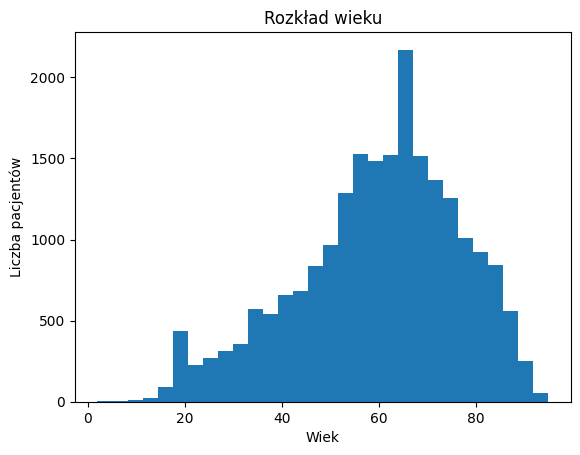

In [14]:
import matplotlib.pyplot as plt

plt.hist(Y.age, bins=30)
plt.title("Rozkład wieku")
plt.xlabel("Wiek")
plt.ylabel("Liczba pacjentów")
plt.show()

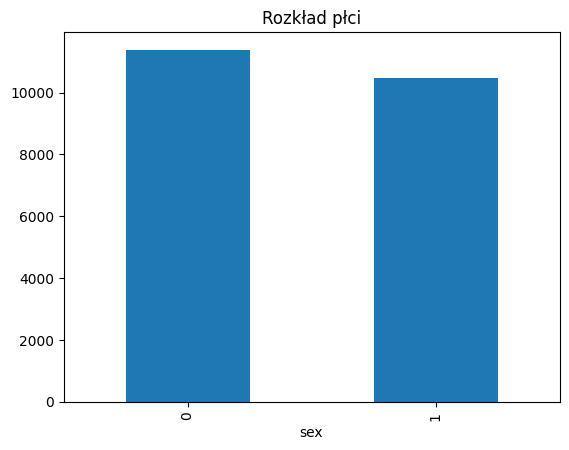

In [15]:
Y.sex.value_counts().plot(kind='bar')
plt.title("Rozkład płci")
plt.show()

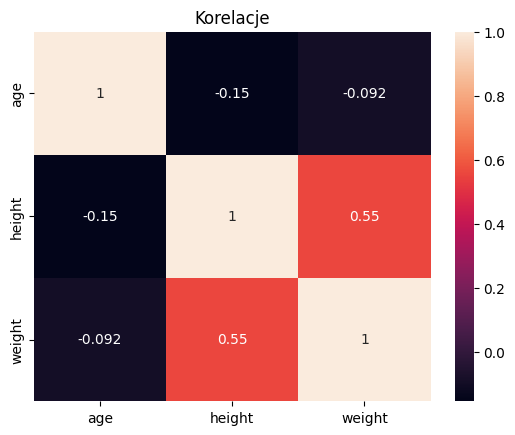

In [20]:
import seaborn as sns

numeric_cols = ["age", "height", "weight"]

Y[numeric_cols].corr()
sns.heatmap(Y[numeric_cols].corr(), annot=True)
plt.title("Korelacje")
plt.show()

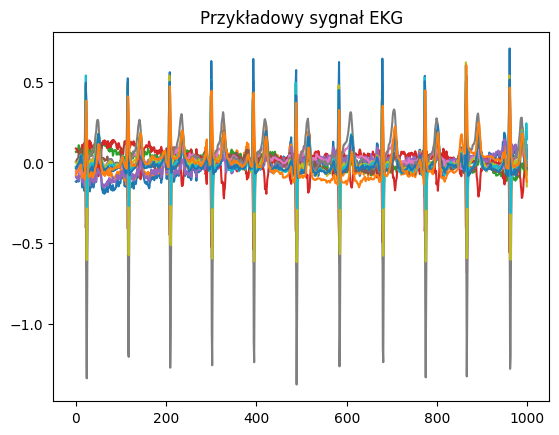

In [28]:
plt.plot(X[0])
plt.title("Przykładowy sygnał EKG")
plt.show()

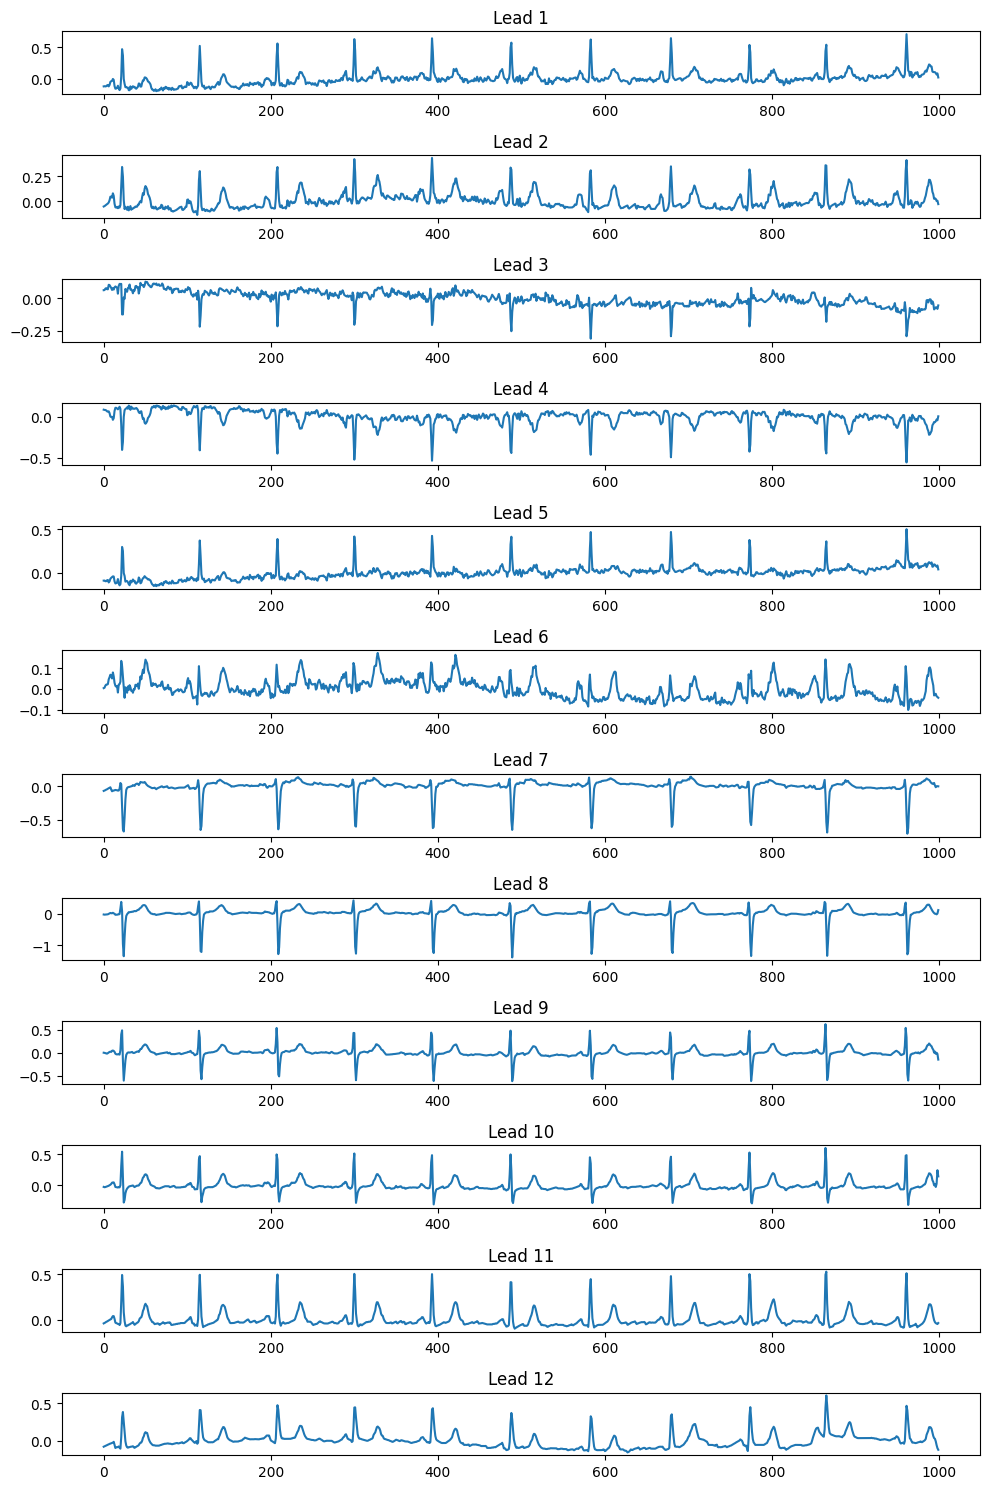

In [29]:
fig, axes = plt.subplots(12, 1, figsize=(10, 15))

for i in range(12):
    axes[i].plot(X[0][:, i])
    axes[i].set_title(f"Lead {i+1}")

plt.tight_layout()
plt.show()

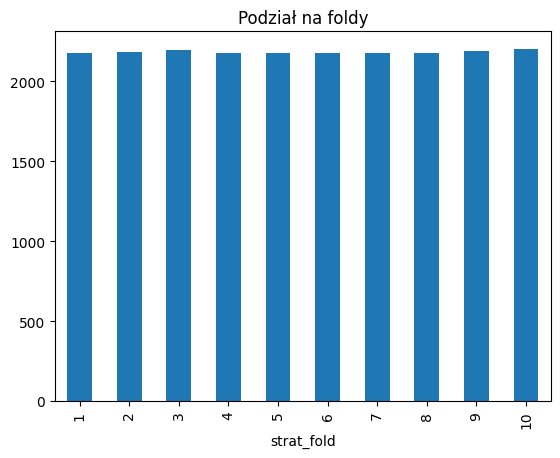

In [30]:
Y.strat_fold.value_counts().sort_index().plot(kind='bar')
plt.title("Podział na foldy")
plt.show()